In [ ]:
"""
Minimal DDPM (Denoising Diffusion Probabilistic Models) on a 2-D toy dataset (two moons). Runs on CPU in about a minute.
    pip install torch scikit-learn matplotlib
    python ddpm_toy.py
"""
import math
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons


In [ ]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# ---------------------------------------------------------------------------
# 1. Noise schedule
#    beta_t      : variance of noise added at step t
#    alpha_t     = 1 - beta_t
#    alpha_bar_t = prod_{s<=t} alpha_s   (lets us jump straight from x_0 to x_t)
# ---------------------------------------------------------------------------

T = 200
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
alpha_bars_prev = torch.cat([torch.ones(1, device=device), alpha_bars[:-1]])
# Posterior variance  beta~_t = (1 - alpha_bar_{t-1}) / (1 - alpha_bar_t) * beta_t
posterior_var = betas * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)

In [ ]:
# ---------------------------------------------------------------------------
# 2. Forward process  q(x_t | x_0) = N( sqrt(alpha_bar_t) x_0 , (1 - alpha_bar_t) I )
#    Reparameterised: x_t = sqrt(alpha_bar_t) x_0 + sqrt(1 - alpha_bar_t) eps
# ---------------------------------------------------------------------------
def q_sample(x0, t, eps):
    ab = alpha_bars[t].unsqueeze(-1)
    return ab.sqrt() * x0 + (1 - ab).sqrt() * eps

In [ ]:
# ---------------------------------------------------------------------------
# 3. Noise-prediction network  eps_theta(x_t, t)
# ---------------------------------------------------------------------------
def timestep_embedding(t, dim=64):
    """Sinusoidal embedding of the integer timestep (as in Transformers)."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
    args = t.float().unsqueeze(-1) * freqs
    return torch.cat([args.sin(), args.cos()], dim=-1)

In [ ]:
class EpsModel(nn.Module):
    def __init__(self, data_dim=2, hidden=128, t_dim=64):
        super().__init__()
        self.t_dim = t_dim
        self.net = nn.Sequential(
            nn.Linear(data_dim + t_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, data_dim),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, timestep_embedding(t, self.t_dim)], dim=-1))

In [ ]:
# ---------------------------------------------------------------------------
# 4. Training  (Algorithm 1 in the paper)
#    L_simple = E_{x0, t, eps} || eps - eps_theta( sqrt(ab_t) x0 + sqrt(1-ab_t) eps , t ) ||^2
# ---------------------------------------------------------------------------
def train(model, data, steps=5000, batch=512, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(steps):
        x0 = data[torch.randint(0, len(data), (batch,), device=device)]
        t = torch.randint(0, T, (batch,), device=device)       # t ~ Uniform{1..T}
        eps = torch.randn_like(x0)                               # eps ~ N(0, I)
        xt = q_sample(x0, t, eps)
        loss = ((eps - model(xt, t)) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        if step % 1000 == 0:
            print(f"step {step:5d}  loss {loss.item():.4f}")

In [ ]:

# ---------------------------------------------------------------------------
# 5. Sampling  (Algorithm 2 in the paper)
#    x_T ~ N(0, I)
#    x_{t-1} = 1/sqrt(alpha_t) * ( x_t - beta_t / sqrt(1-ab_t) * eps_theta(x_t,t) ) + sigma_t z
# ---------------------------------------------------------------------------
@torch.no_grad()
def sample(model, n=2000, return_traj=False):
    x = torch.randn(n, 2, device=device)
    traj = [x.cpu()]
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        eps_hat = model(x, tt)
        mean = (x - betas[t] / (1 - alpha_bars[t]).sqrt() * eps_hat) / alphas[t].sqrt()
        if t > 0:
            x = mean + posterior_var[t].sqrt() * torch.randn_like(x)
        else:
            x = mean                                             # no noise at the last step
        traj.append(x.cpu())
    return (x, traj) if return_traj else x


step     0  loss 0.9564
step  1000  loss 0.5521
step  2000  loss 0.4956
step  3000  loss 0.5195
step  4000  loss 0.4532
saved ddpm_toy.png


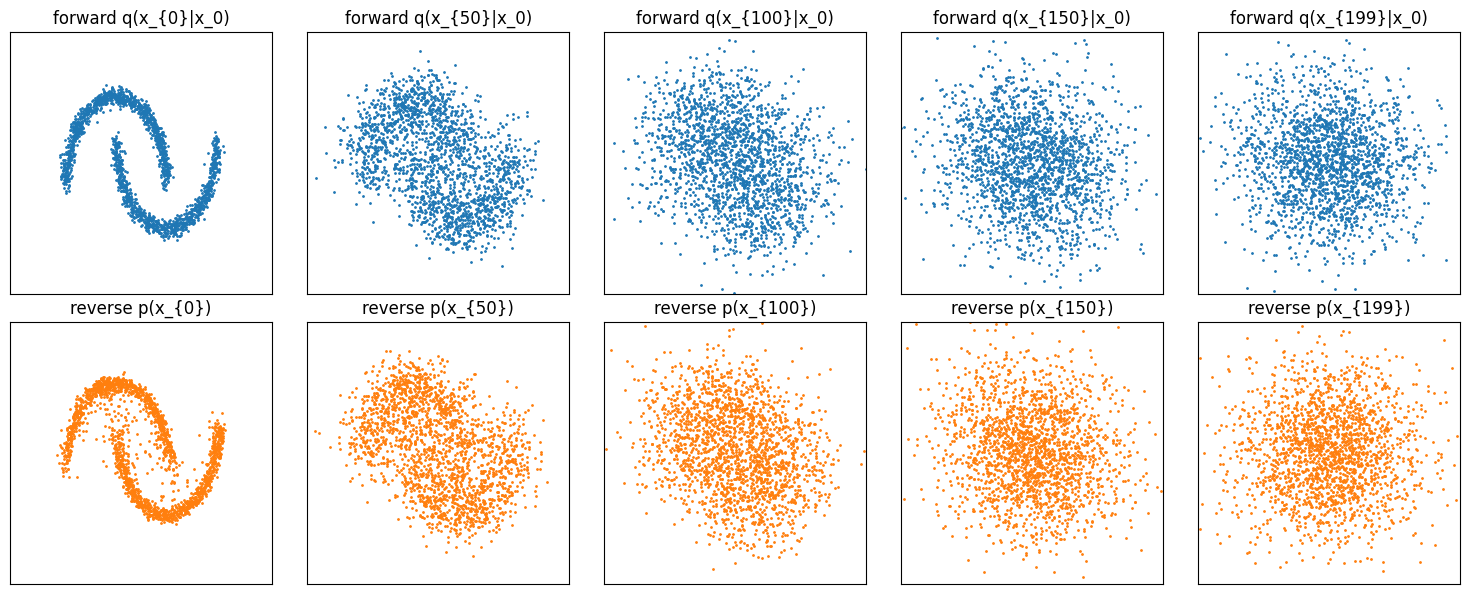

In [ ]:
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    X, _ = make_moons(n_samples=10000, noise=0.05)
    data = torch.tensor(X, dtype=torch.float32, device=device)
    data = (data - data.mean(0)) / data.std(0)                   # normalise to ~unit variance

    model = EpsModel().to(device)
    train(model, data)

    samples, traj = sample(model, return_traj=True)

    # Plot: forward noising of real data (top) and reverse denoising (bottom)
    shown = [0, 50, 100, 150, 199]
    fig, axes = plt.subplots(2, len(shown), figsize=(3 * len(shown), 6))
    x0 = data[:2000]
    for i, t in enumerate(shown):
        xt = q_sample(x0, torch.full((len(x0),), t, device=device), torch.randn_like(x0)).cpu()
        axes[0, i].scatter(xt[:, 0], xt[:, 1], s=1)
        axes[0, i].set_title(f"forward q(x_{{{t}}}|x_0)")
        xr = traj[T - t]                                         # traj[k] is x at step T-k
        axes[1, i].scatter(xr[:, 0], xr[:, 1], s=1, c="tab:orange")
        axes[1, i].set_title(f"reverse p(x_{{{t}}})")
    for ax in axes.flat:
        ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.savefig("ddpm_toy.png", dpi=120)
    print("saved ddpm_toy.png")